# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 42     |  |
| :-------------|:-------------|
| Floris Dekker| 6325556 |
| Jesse Dijkzeul| 6542956 |
| Daniel Shou| 6501540 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Jesse', 'Floris',]#'Daniel']

## Opdracht 1: Planning.

| Planning Groep: 42     |Tijdstip / Tijdspanne  |
|---|---|
| arduino kalibreren | 11:30 |
| opdracht 2: testen meetopstelling | 12:00 |
| Pauze 1| 13.30 |
| iteratie 0| 14:45 |
| iteratie 1| 16:30 |
| checken door TA| 17:00|

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [42]
![kalibratie opstelling foto](20260318_113733.jpg)


alpha: 0.03415368647420958, beta: -1.0733230565557021


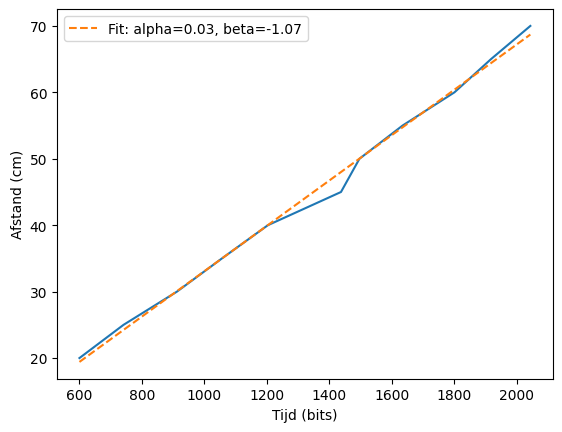

In [3]:
# verwerk hier jullie kalibratiemetingen

distance_0 = np.array([20, 25, 30, 35, 40,45, 50, 55, 60, 65, 70]) #cm
tijd_0 = np.array([600, 741, 912, 1056, 1203, 1437, 1496, 1634, 1800, 1917, 2043]) #bits


def linfunc(x, alpha,beta):
    return alpha * x + beta

from scipy.optimize import curve_fit
popt, pcov = curve_fit(linfunc, tijd_0, distance_0)
alpha, beta = popt
print(f"alpha: {alpha}, beta: {beta}")

plt.figure()
plt.plot(tijd_0, distance_0)
plt.plot(tijd_0, linfunc(tijd_0, alpha, beta), linestyle='--', label='Fit: alpha={:.2f}, beta={:.2f}'.format(*popt))
plt.xlabel('Tijd (bits)')
plt.ylabel('Afstand (cm)')
plt.legend()
plt.show()




## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0   0  40   0  30  1.0
1   0  30   0  20  2.0
2   0  10   0  20  3.0
3  40   0  30   0  4.0
4  30   0  20   0  5.0
5  10   0  20   0  6.0
6  10   0   0  10  7.0


c:\Users\flori\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


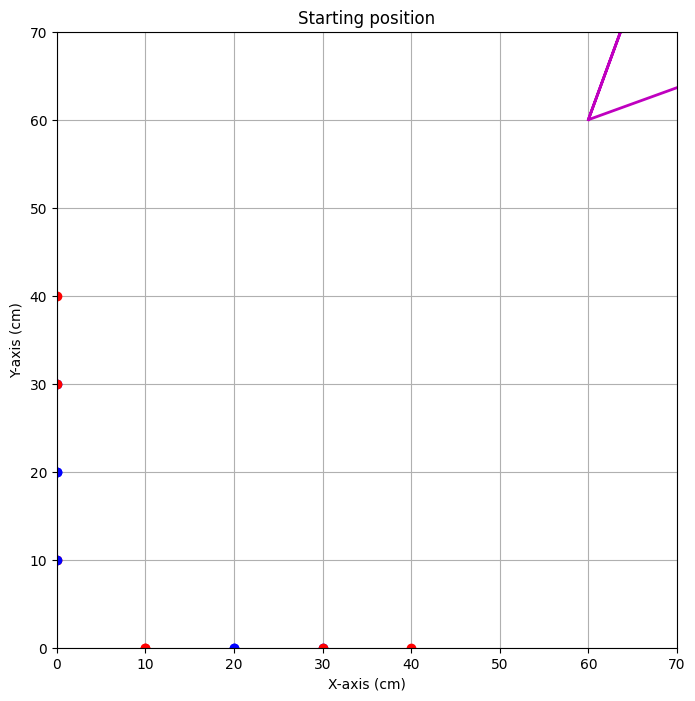

c:\Users\flori\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)



Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=145.594
end iteration 2 with average mismatch=133.981


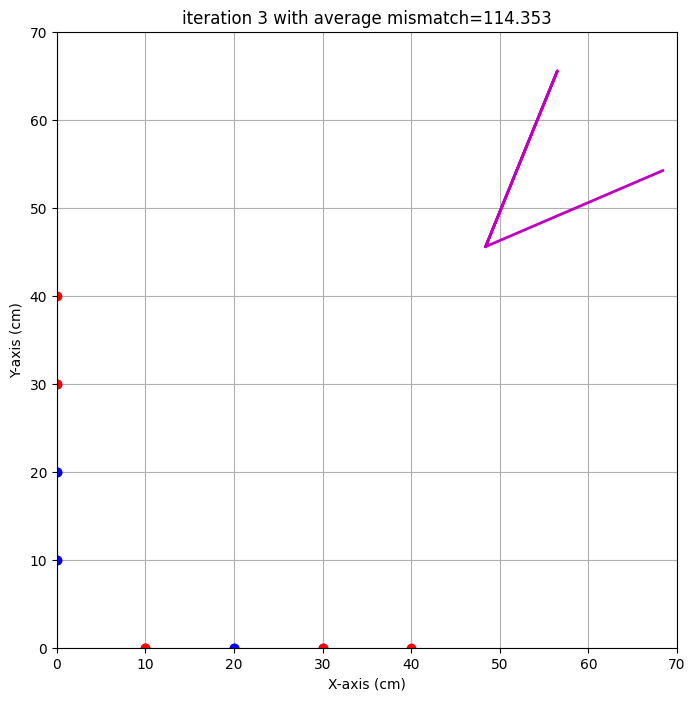

end iteration 3 with average mismatch=114.353


c:\Users\flori\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


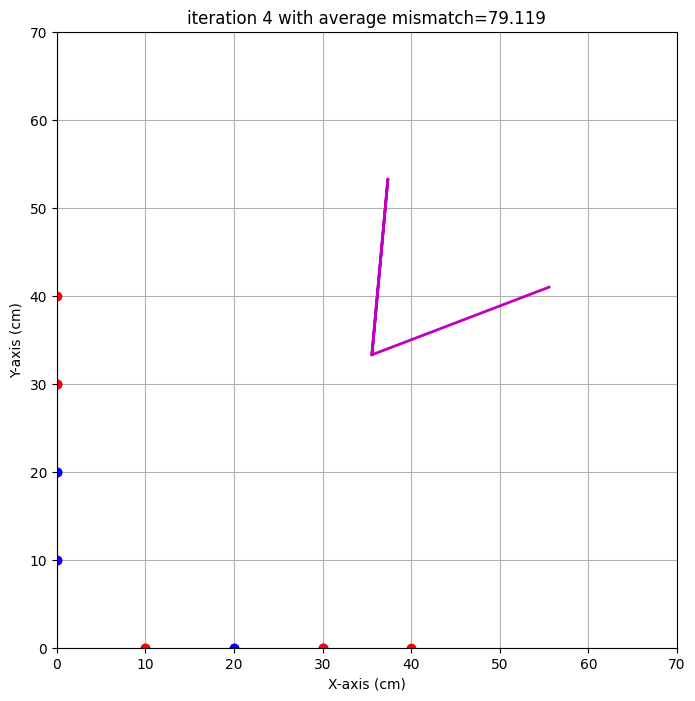

c:\Users\flori\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


end iteration 4 with average mismatch=79.119


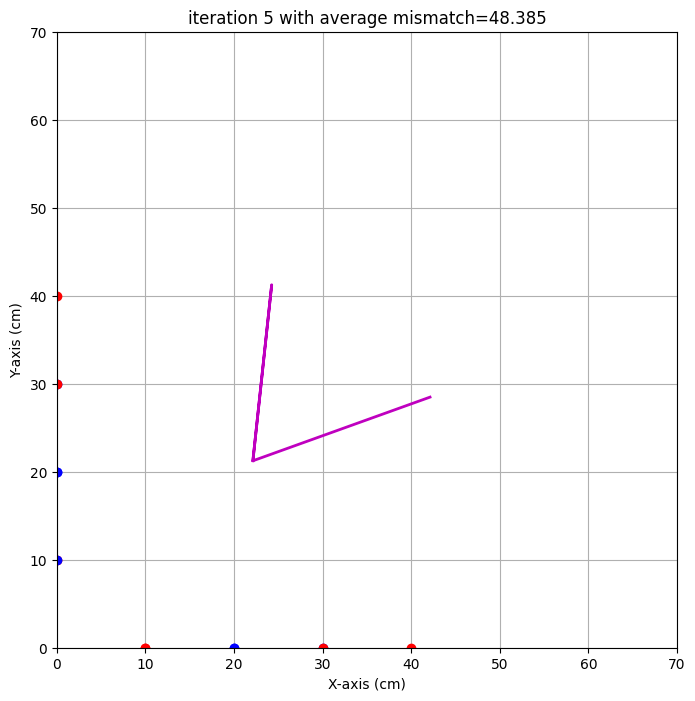

c:\Users\flori\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


end iteration 5 with average mismatch=48.385


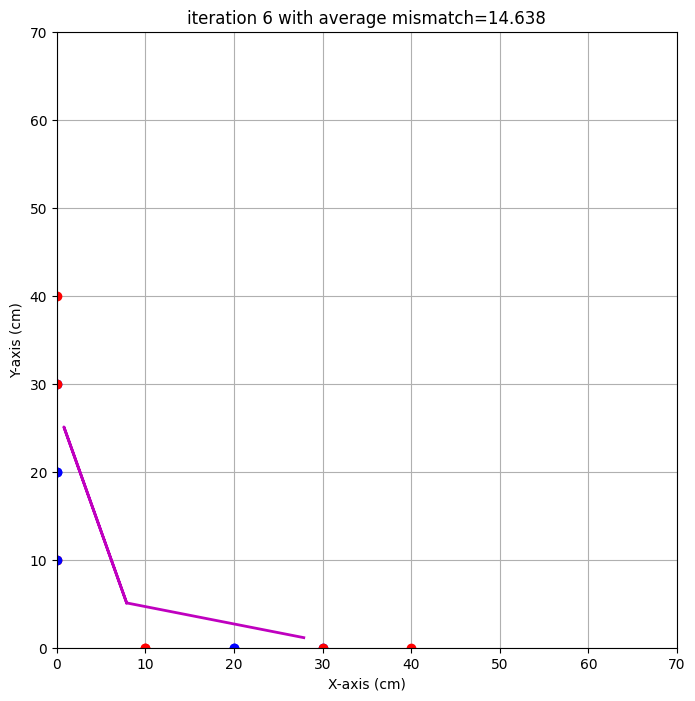

c:\Users\flori\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


end iteration 6 with average mismatch=14.638


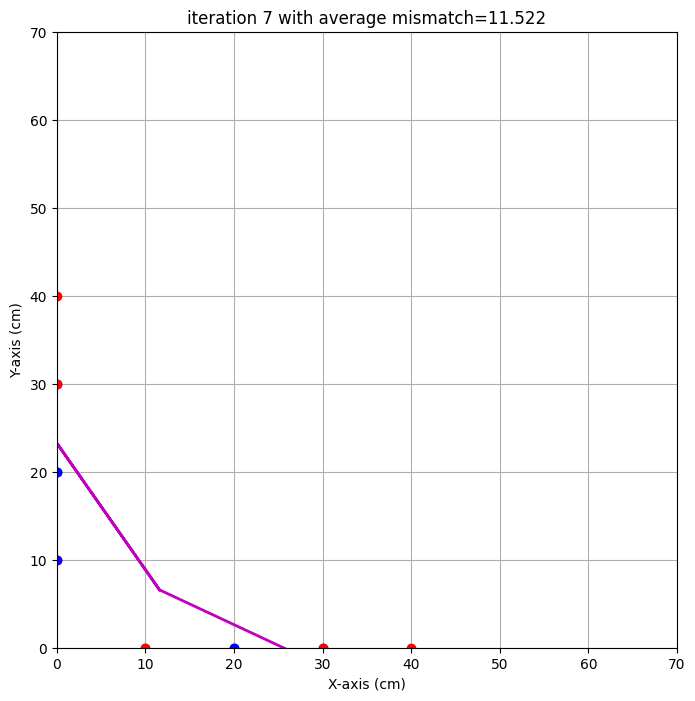

end iteration 7 with average mismatch=11.522
end iteration 8 with average mismatch=11.402
end iteration 9 with average mismatch=11.337
end iteration 10 with average mismatch=11.259
end iteration 11 with average mismatch=11.253
end iteration 12 with average mismatch=11.253
end iteration 13 with average mismatch=11.225
end iteration 14 with average mismatch=11.225
end iteration 15 with average mismatch=11.225
end iteration 16 with average mismatch=11.225
end iteration 17 with average mismatch=11.225
end iteration 18 with average mismatch=11.225
end iteration 19 with average mismatch=11.225
end iteration 20 with average mismatch=11.225
end iteration 21 with average mismatch=11.225
end iteration 22 with average mismatch=11.225
end iteration 23 with average mismatch=11.225
end iteration 24 with average mismatch=11.225
end iteration 25 with average mismatch=11.225
end iteration 26 with average mismatch=11.222
end iteration 27 with average mismatch=11.222
end iteration 28 with average mismatc

c:\Users\flori\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


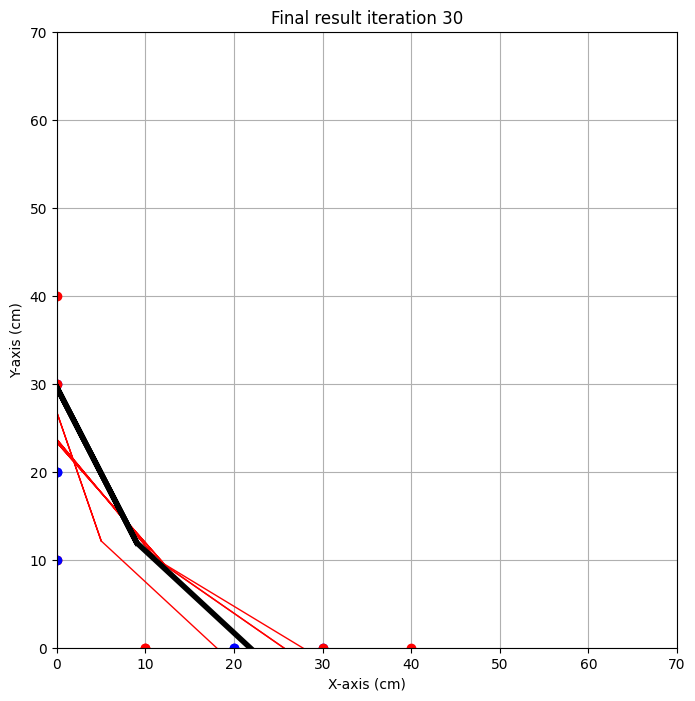

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,1.0],
    [0,30,0,20,2.0],
    [0,10,0,20,3.0],
    [40,0,30,0,4.0],
    [30,0,20,0,5.0],
    [10,0,20,0,6.0],
    [10,0,0,10,7.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 9.0 cm met een standaardafwijking van 4.0 cm 
y0: 11.9 cm met een standaardafwijking van 2.6 cm 
alpha: -43.0 graden met een standaardafwijking van 11.6 graad 
beta: -27.1 graden met een standaardafwijking van 14.2 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Floris]
![algoritme 1](20260318_135328.jpg)
verbeterd blokschema
![algoritme extra blokschema](20260318_142418.jpg)

#### algoritme [Daniel]
![algoritme 2](20260318_135339.jpg)

#### algoritme [Jesse]
![algoritme 3](20260318_141506.jpg)

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': 36,
           'alpha' : -20,
           'beta' : 15,
          }
           


# iteratie 0 algorithme Jesse:
# meetronde 1

d_y = np.array([74,67,64,199])/2
d_x = np.array([195,199,82,80])/2
# middelwaarde van d_x en d_y berekenen zonder te grote waarden.

d_x_mean = (d_x[0]+d_x[1]+d_x[2]) / 3
d_y_mean = (d_y[2]+d_y[3]) / 2

# meetronde 2
# voor x-as

x2 = np.array([d_x_mean,d_x_mean+4])
d_x2 = np.array([65,63])/2

#voor y-as

y2 = np.array([d_y_mean,d_y_mean+4])
d_y2 = np.array([199,77])/2





# iterartie 0 algorithme Floris:
# 

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Jesse' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [29,0,23,0,74],
    [39,0,33,0,67],
    [49,0,43,0,64],
    #[59,0,53,0,199],
    #[0,29,0,23,195],
    #[0,39,0,33,199],
    [0,49,0,43,82],
    [0,59,0,53,80],
    [x2[0]+3,0,x2[0]-3,0,65],
    [x2[1]+3,0,x2[0]-3,0,63],
    #[0,y2[0]+3,0,y2[0]-3,199],
    [0,y2[1]+3,y2[1]-3,77],
    ]),
       'Floris' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,51,0,45,77],
    #[0,53,0,47,76],
    [0,55,0,49,78],
    [0,59,0,53,81],
    [0,63,0,57,81],
    #[0,67,0,61,84],
    #[0,71,0,65,190],
    #[51,0,45,0,196],
    [41,0,35,0,62],
    [45,0,39,0,61],
    [47,0,41,0,58],
    #[49,0,43,0,188],
    [37,0,31,0,69],
    [33,0,27,0,68],
    #[29,0,23,0,70],
    #[25,0,19,0,75],
    ])   }


## Opdracht 7: Evaluatie.

Jesse
Running the imaging algorithm with the following data:
          xs     ys         xr  yr     R
0  29.000000   0.00  23.000000   0  74.0
1  39.000000   0.00  33.000000   0  67.0
2  49.000000   0.00  43.000000   0  64.0
3   0.000000  49.00   0.000000  43  82.0
4   0.000000  59.00   0.000000  53  80.0
5  82.333333   0.00  76.333333   0  65.0
6  86.333333   0.00  76.333333   0  63.0
7   0.000000  72.75  66.750000  77   NaN


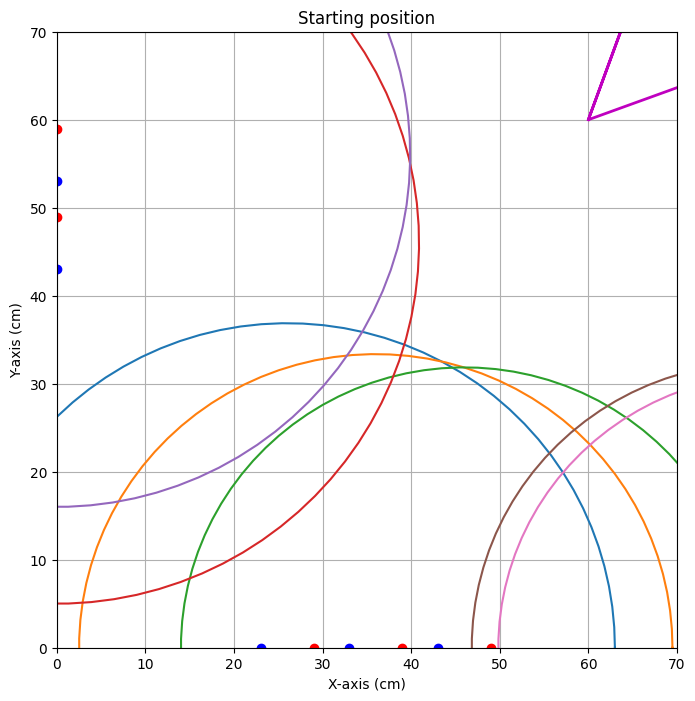


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with ave

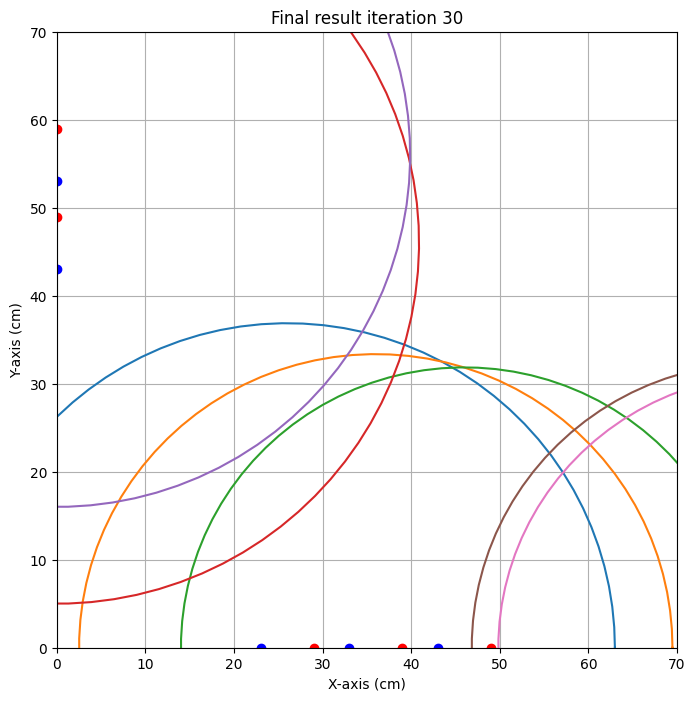

{'alpha': nan, 'alpha_eps': 0.0, 'beta': nan, 'beta_eps': 0.0, 'x0': nan, 'x0_eps': 0.0, 'y0': nan, 'y0_eps': 0.0}
Floris
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  55   0  49  78
1   0  59   0  53  81
2   0  63   0  57  81
3  41   0  35   0  62
4  45   0  39   0  61
5  47   0  41   0  58
6  37   0  31   0  69
7  33   0  27   0  68


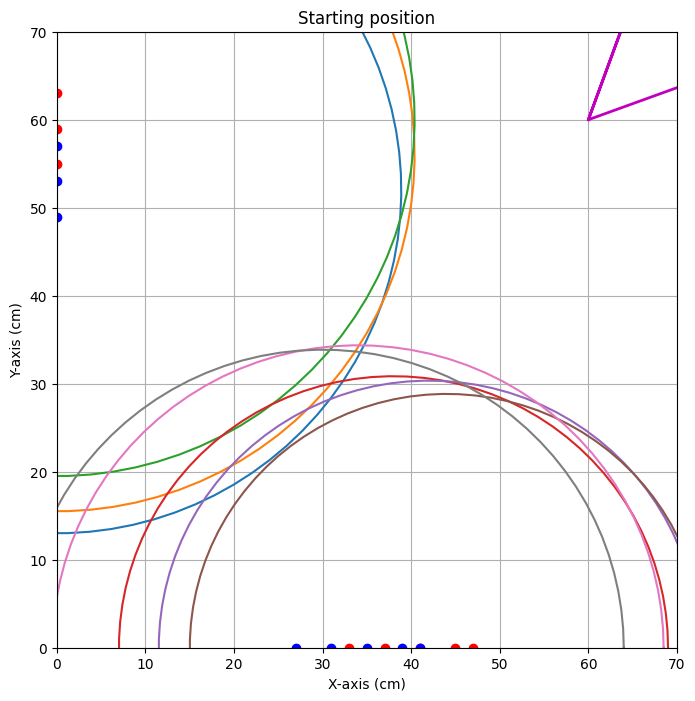


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=62.337


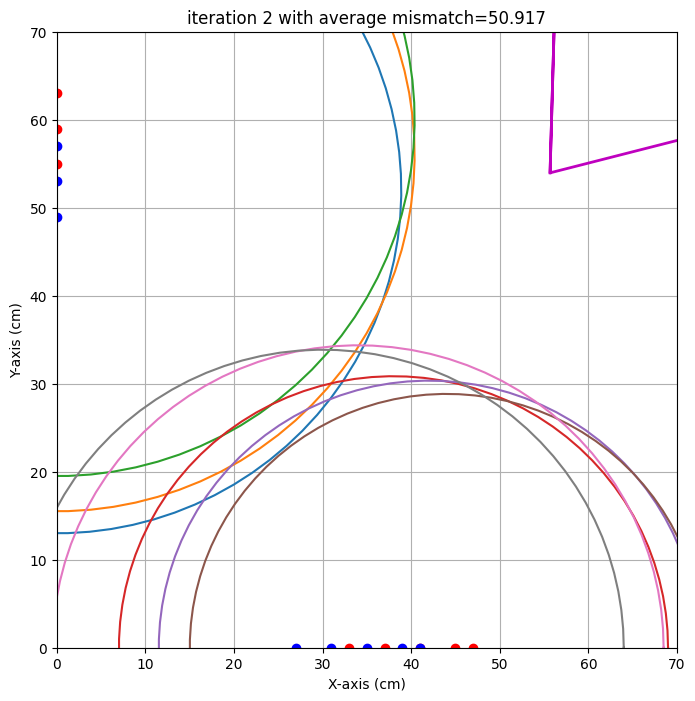

end iteration 2 with average mismatch=50.917


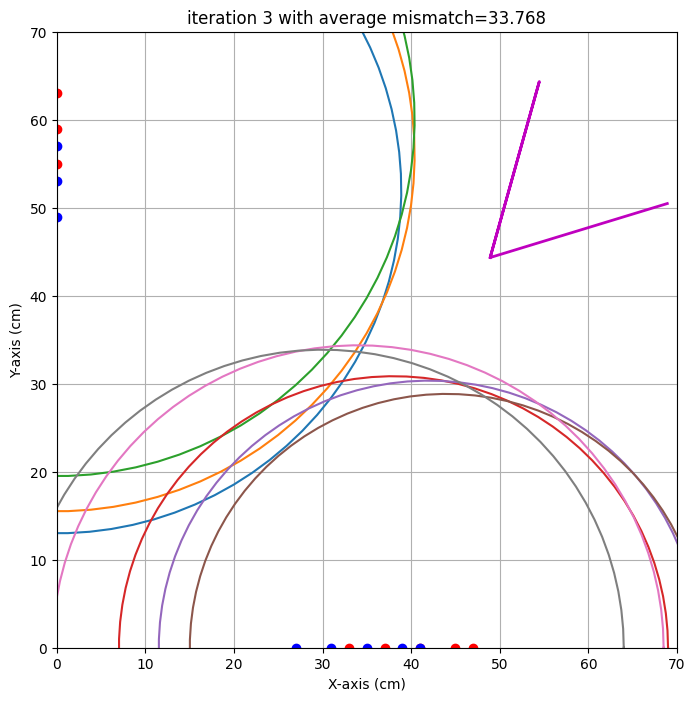

end iteration 3 with average mismatch=33.768


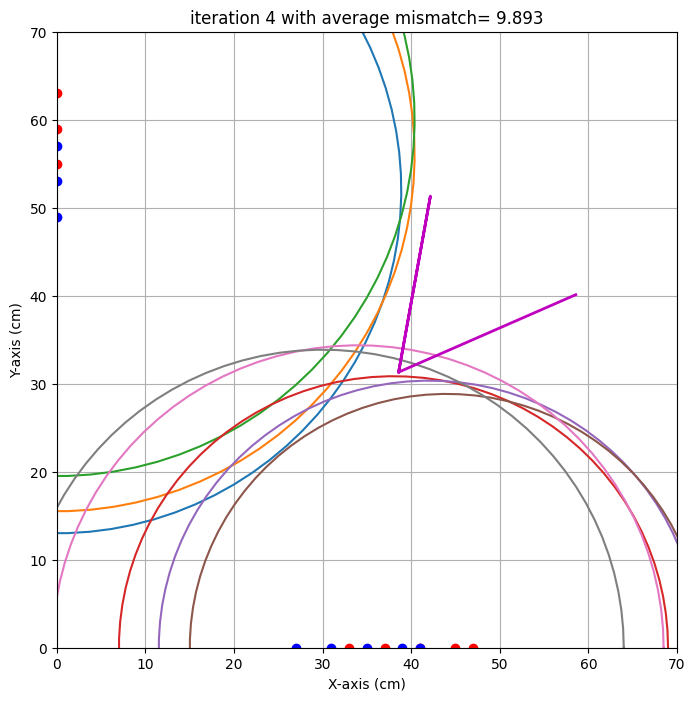

end iteration 4 with average mismatch= 9.893


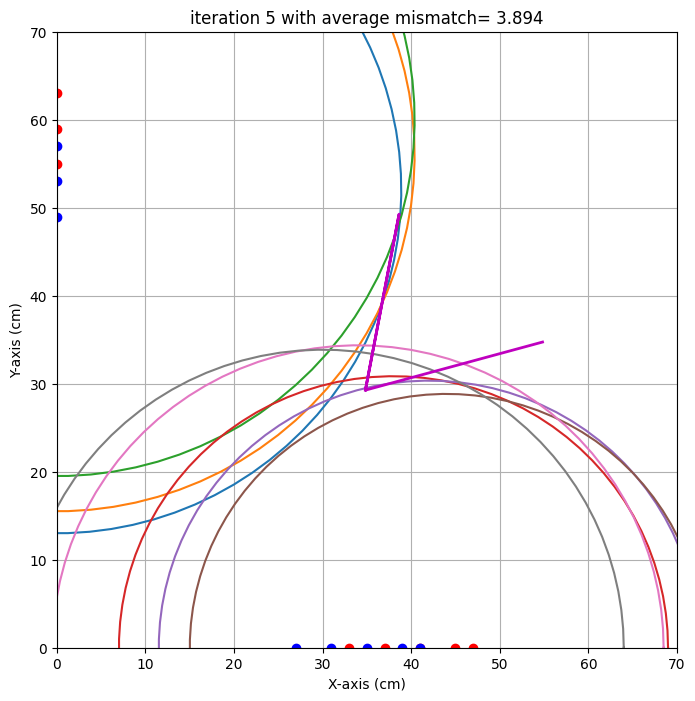

end iteration 5 with average mismatch= 3.894
end iteration 6 with average mismatch= 3.699


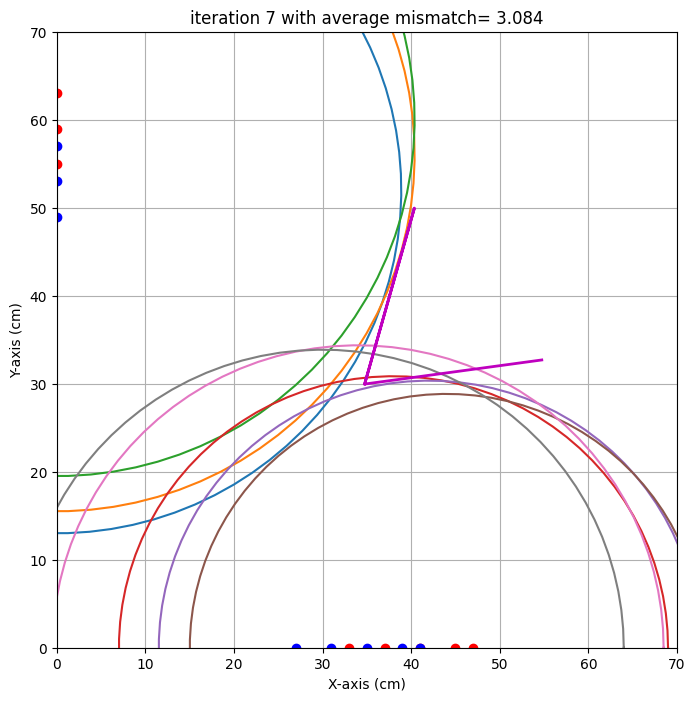

end iteration 7 with average mismatch= 3.084


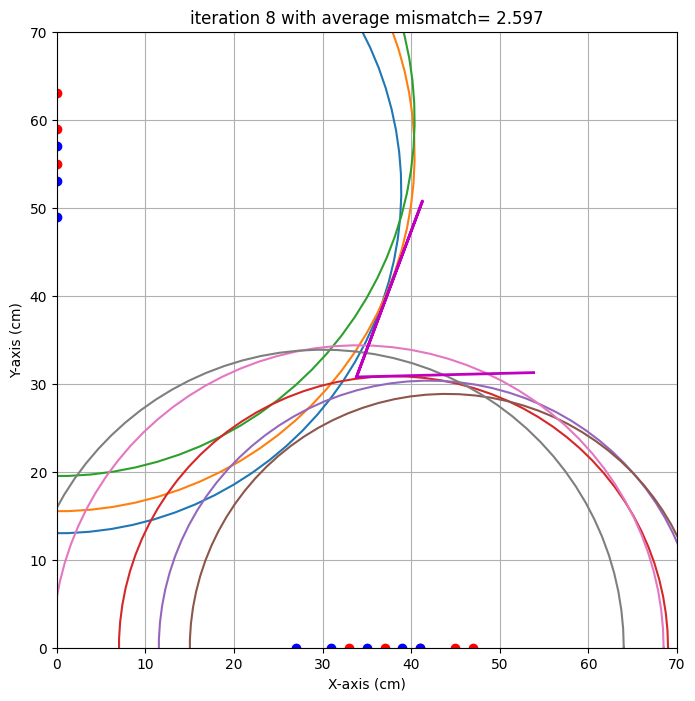

end iteration 8 with average mismatch= 2.597


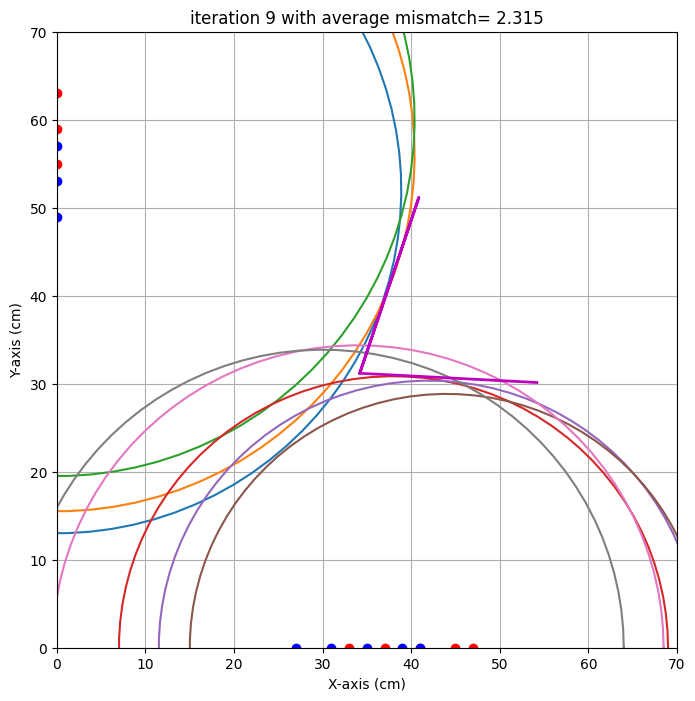

end iteration 9 with average mismatch= 2.315
end iteration 10 with average mismatch= 2.221


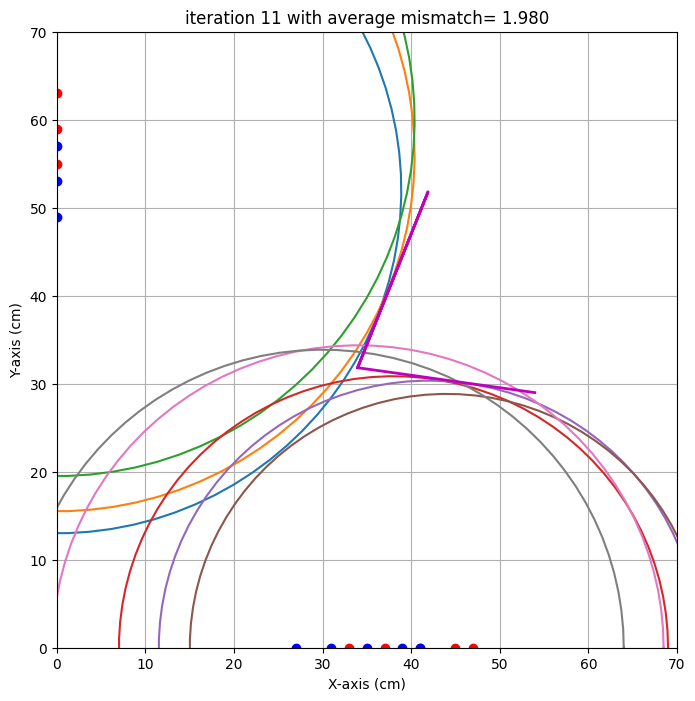

end iteration 11 with average mismatch= 1.980
end iteration 12 with average mismatch= 1.878
end iteration 13 with average mismatch= 1.871
end iteration 14 with average mismatch= 1.809
end iteration 15 with average mismatch= 1.808


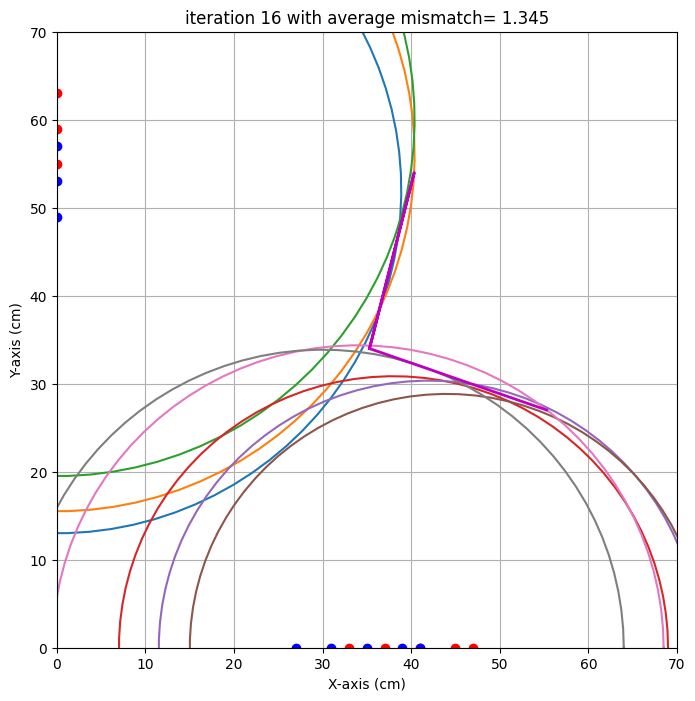

end iteration 16 with average mismatch= 1.345
end iteration 17 with average mismatch= 1.321
end iteration 18 with average mismatch= 1.305
end iteration 19 with average mismatch= 1.294
end iteration 20 with average mismatch= 1.292
end iteration 21 with average mismatch= 1.283
end iteration 22 with average mismatch= 1.283
end iteration 23 with average mismatch= 1.231
end iteration 24 with average mismatch= 1.222
end iteration 25 with average mismatch= 1.218
end iteration 26 with average mismatch= 1.218
end iteration 27 with average mismatch= 1.218
end iteration 28 with average mismatch= 1.218
end iteration 29 with average mismatch= 1.218
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.218
###############################################################################
end of iteration  30
Best alpha= -18.80 with uncertainty=   6.17
Best beta =  12.55 with uncertainty=   6.97
Best x0   = 

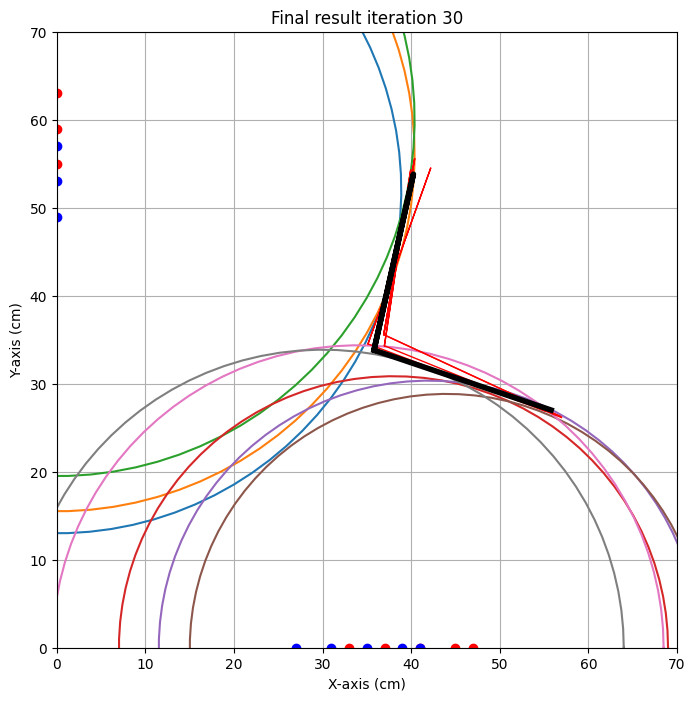

{'alpha': -18.802557787495942, 'alpha_eps': 6.174457962508839, 'beta': 12.549687435677695, 'beta_eps': 6.967332272455634, 'x0': 35.7982060556998, 'x0_eps': 1.1765882025277818, 'y0': 33.8157190263936, 'y0_eps': 1.760246763984341}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Jesse 
x0 target is : 33.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 36.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : -20.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : 15.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 

Floris 
x0 target is : 33.0. Gevonden waarde: 35.8 cm met een standaardafwijking van 1.2 cm 
y0 target is : 36.0. Gevonden waarde: 33.8 cm met een standaardafwijking van 1.8 cm 
alpha target is : -20.0. Gevonden waarde: -18.8 graden met een standaardafwijking van 6.2 graad 
beta target is : 15.0. Gevonden waarde: 12.5 graden met een standaardafwijking van 7.0 graad 



## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_eind.jpg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  48   0  42   0  72
1  55   0  47   0  73
2  43   0  35   0  72
3   0  48   0  42  69
4   0  55   0  47  70
5   0  43   0  35  71


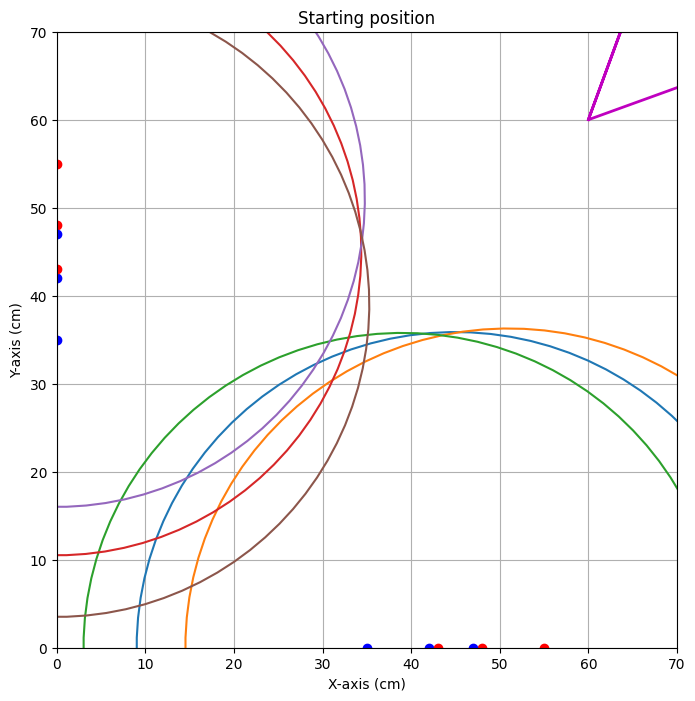


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.576


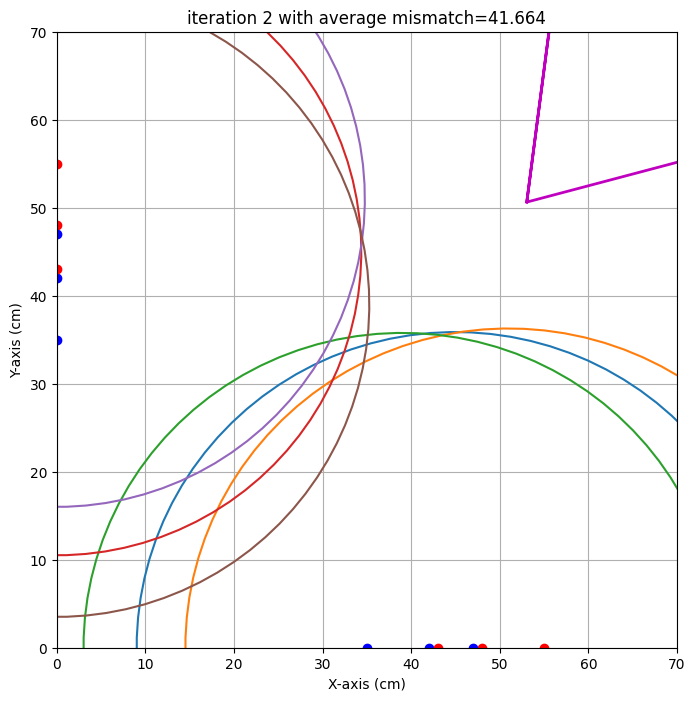

end iteration 2 with average mismatch=41.664


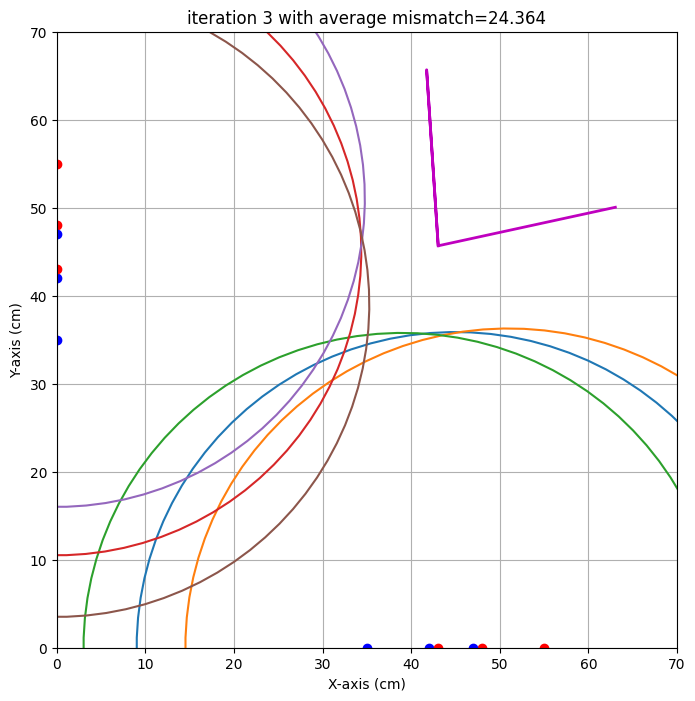

end iteration 3 with average mismatch=24.364


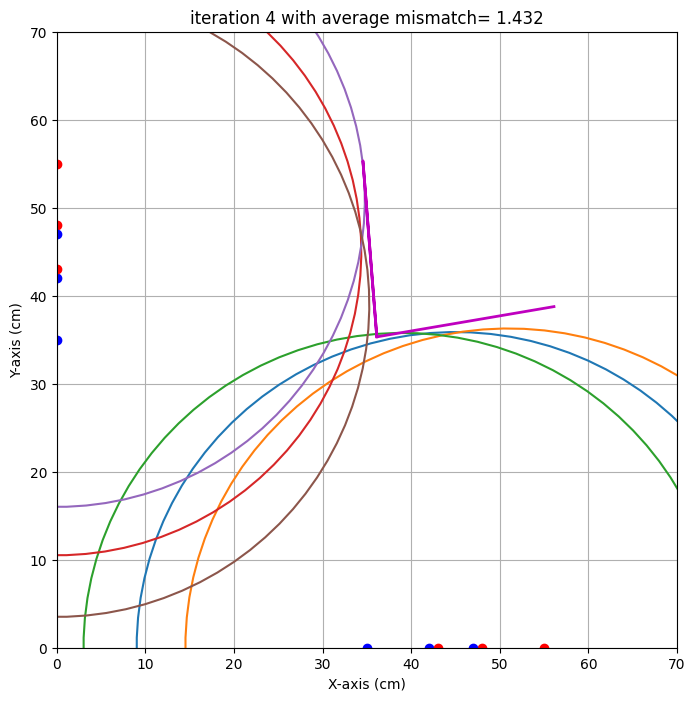

end iteration 4 with average mismatch= 1.432


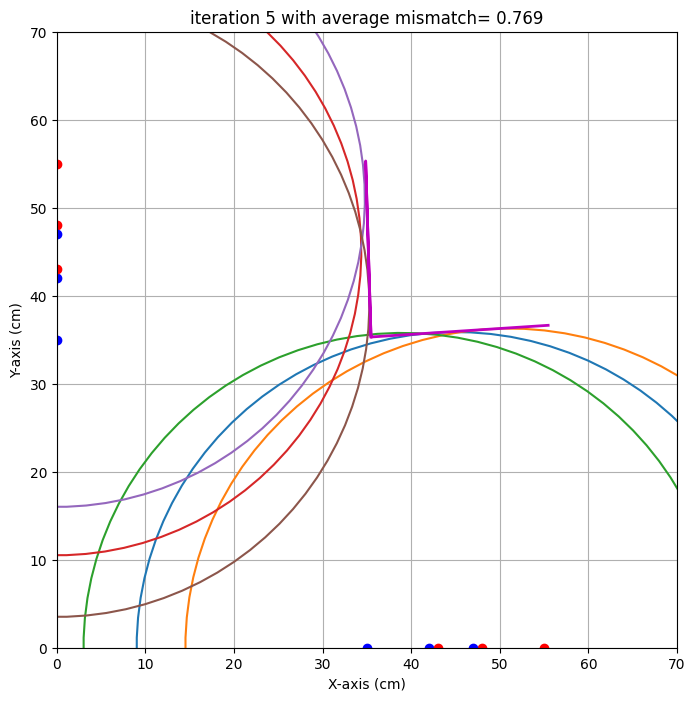

end iteration 5 with average mismatch= 0.769


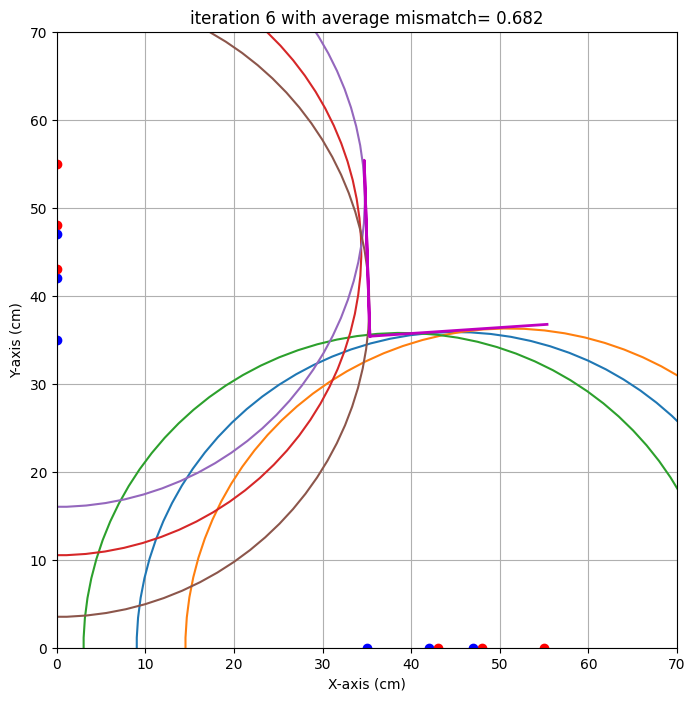

end iteration 6 with average mismatch= 0.682
end iteration 7 with average mismatch= 0.620
end iteration 8 with average mismatch= 0.617
end iteration 9 with average mismatch= 0.613
end iteration 10 with average mismatch= 0.596
end iteration 11 with average mismatch= 0.594


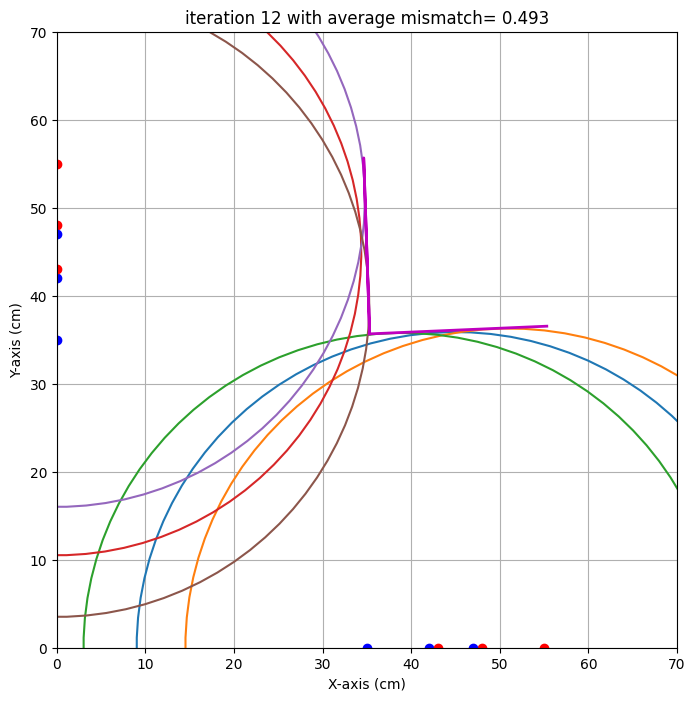

end iteration 12 with average mismatch= 0.493
end iteration 13 with average mismatch= 0.483
end iteration 14 with average mismatch= 0.475
end iteration 15 with average mismatch= 0.475
end iteration 16 with average mismatch= 0.475
end iteration 17 with average mismatch= 0.475
end iteration 18 with average mismatch= 0.475
end iteration 19 with average mismatch= 0.475
end iteration 20 with average mismatch= 0.475
end iteration 21 with average mismatch= 0.475
end iteration 22 with average mismatch= 0.475
end iteration 23 with average mismatch= 0.475
end iteration 24 with average mismatch= 0.475
end iteration 25 with average mismatch= 0.475
end iteration 26 with average mismatch= 0.475
end iteration 27 with average mismatch= 0.475
end iteration 28 with average mismatch= 0.475
end iteration 29 with average mismatch= 0.475
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.475
#################

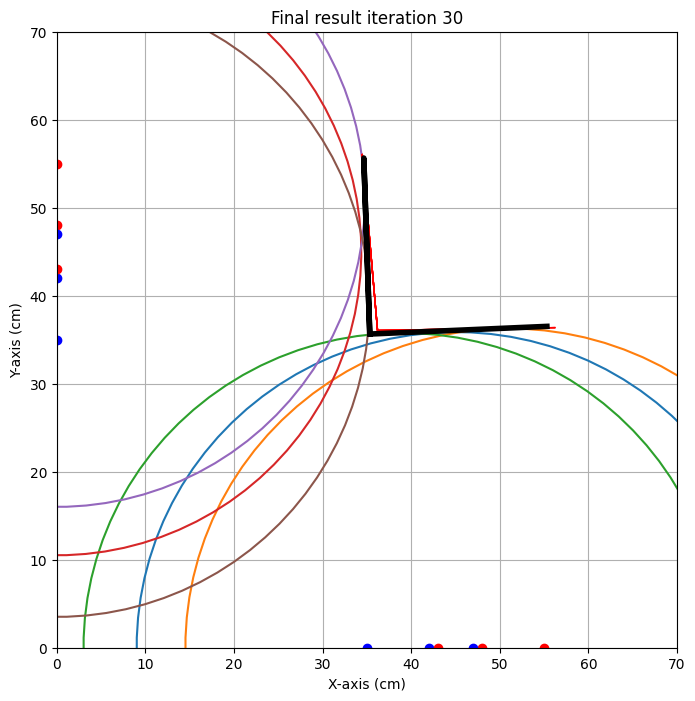

{'alpha': 2.4971566402977112, 'alpha_eps': 1.6043526383584747, 'beta': -1.9291580475752328, 'beta_eps': 2.99176194390044, 'x0': 35.322764328816, 'x0_eps': 0.8780501084815953, 'y0': 35.6454663701271, 'y0_eps': 0.4183094703359913}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  48   0  42   0  55
1  45   0  37   0  55
2  55   0  47   0  54
3   0  48   0  42  81
4   0  45   0  37  79
5   0  43   0  35  79


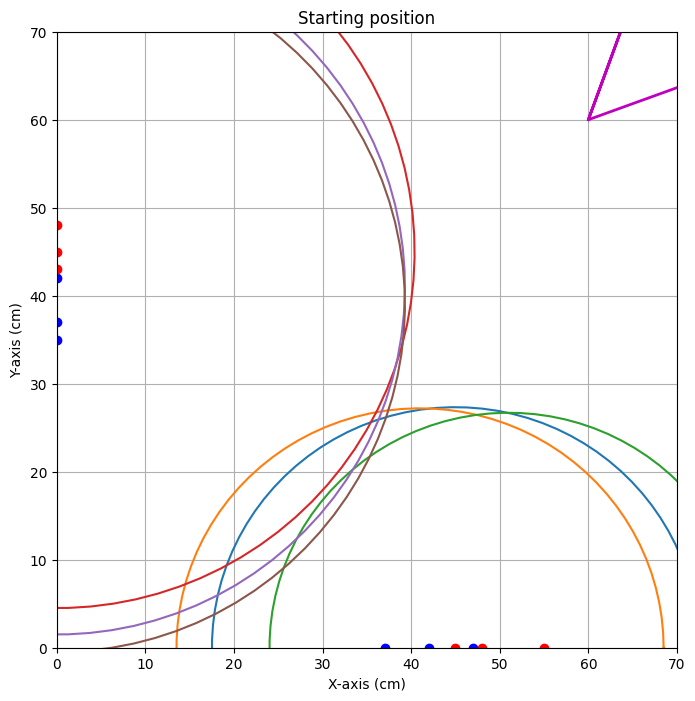


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=64.345


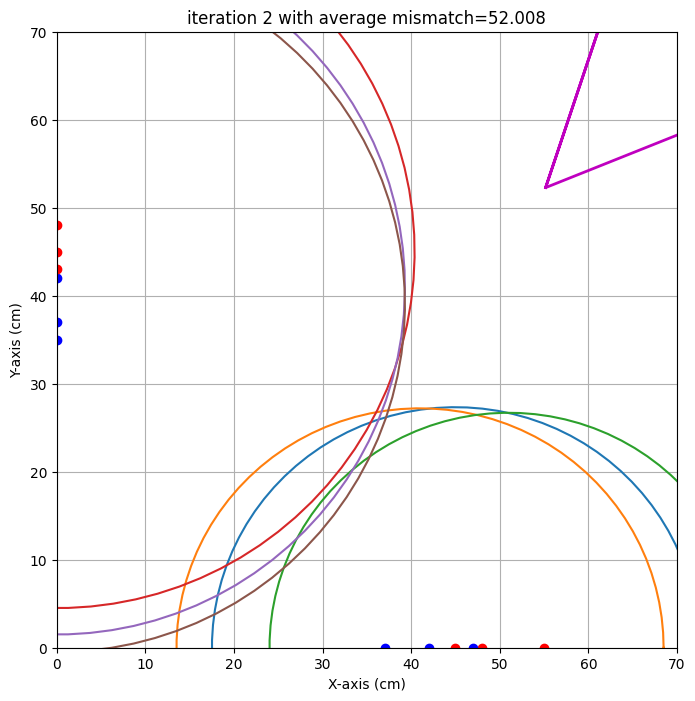

end iteration 2 with average mismatch=52.008


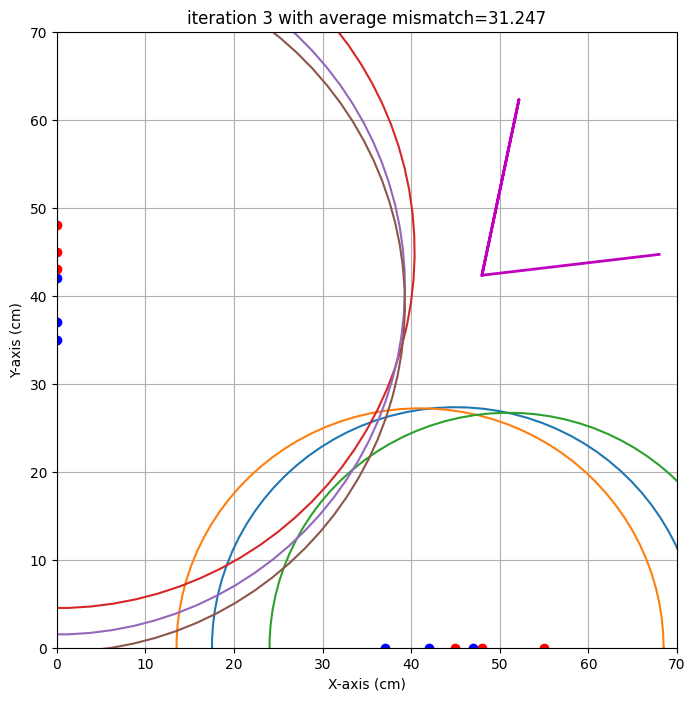

end iteration 3 with average mismatch=31.247


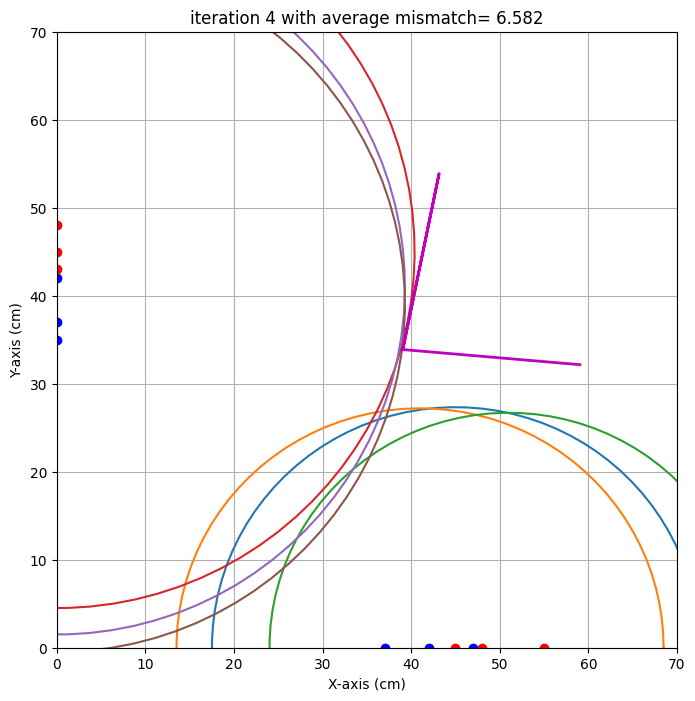

end iteration 4 with average mismatch= 6.582


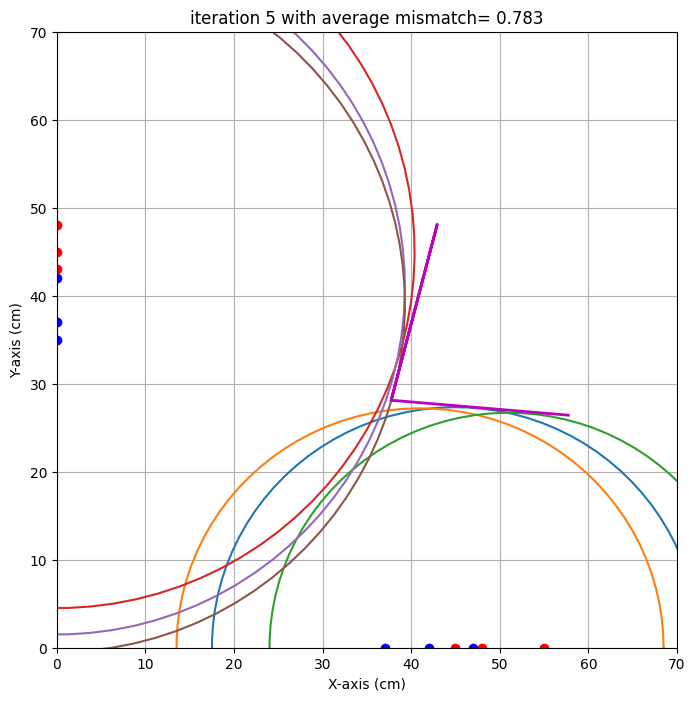

end iteration 5 with average mismatch= 0.783


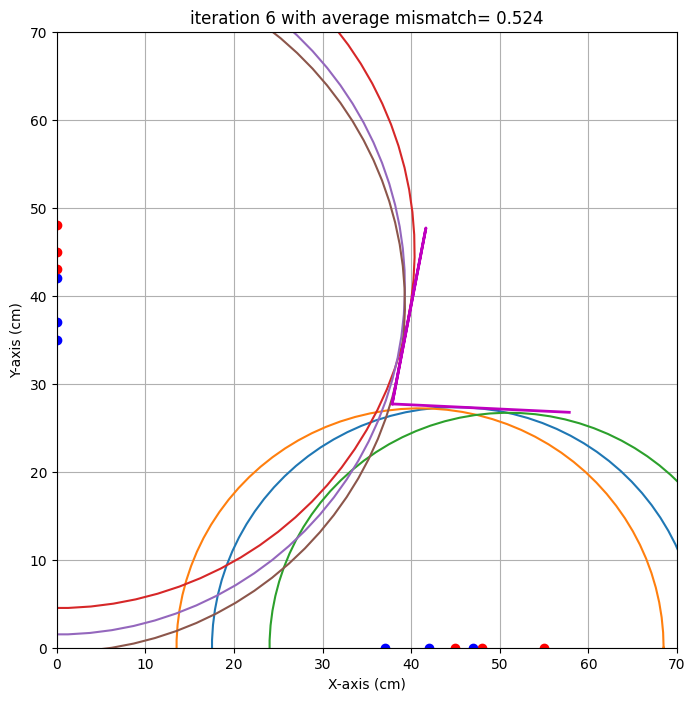

end iteration 6 with average mismatch= 0.524
end iteration 7 with average mismatch= 0.522
end iteration 8 with average mismatch= 0.521
end iteration 9 with average mismatch= 0.520
end iteration 10 with average mismatch= 0.520
end iteration 11 with average mismatch= 0.520
end iteration 12 with average mismatch= 0.487
end iteration 13 with average mismatch= 0.451
end iteration 14 with average mismatch= 0.448
end iteration 15 with average mismatch= 0.447
end iteration 16 with average mismatch= 0.447
end iteration 17 with average mismatch= 0.447
end iteration 18 with average mismatch= 0.447
end iteration 19 with average mismatch= 0.447
end iteration 20 with average mismatch= 0.447
end iteration 21 with average mismatch= 0.447
end iteration 22 with average mismatch= 0.447
end iteration 23 with average mismatch= 0.447
end iteration 24 with average mismatch= 0.447
end iteration 25 with average mismatch= 0.447
end iteration 26 with average mismatch= 0.447
end iteration 27 with average mismatch

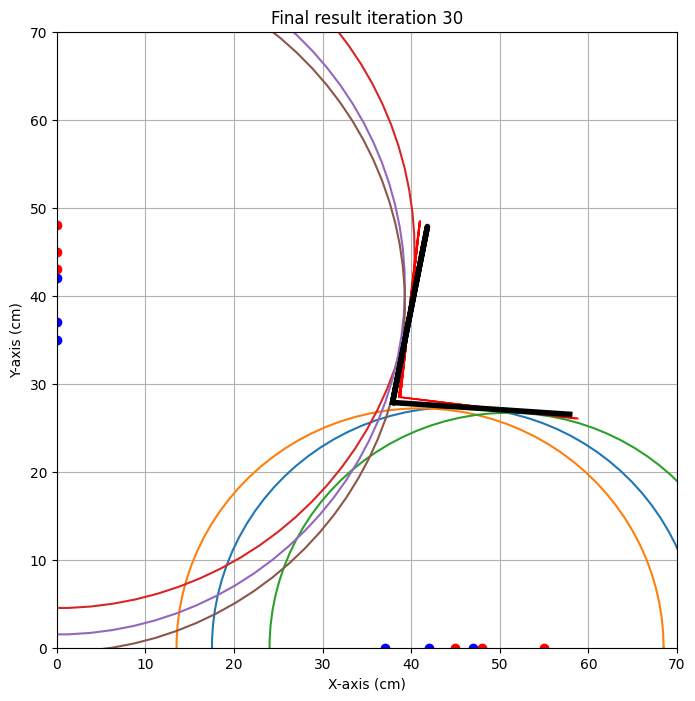

{'alpha': -3.8483777653191242, 'alpha_eps': 3.106330523506213, 'beta': 11.147440031062361, 'beta_eps': 4.766441237028765, 'x0': 37.89422916585404, 'x0_eps': 0.8819098117025064, 'y0': 27.86795366290643, 'y0_eps': 0.6104445610237086}
locatie 1 
x0 target is : 35.0. Gevonden waarde: 35.3 cm met een standaardafwijking van 0.9 cm 
y0 target is : 36.0. Gevonden waarde: 35.6 cm met een standaardafwijking van 0.4 cm 
alpha target is : -10.0. Gevonden waarde: 2.5 graden met een standaardafwijking van 1.6 graad 
beta target is : 8.0. Gevonden waarde: -1.9 graden met een standaardafwijking van 3.0 graad 

locatie 2 
x0 target is : 40.5. Gevonden waarde: 37.9 cm met een standaardafwijking van 0.9 cm 
y0 target is : 27.5. Gevonden waarde: 27.9 cm met een standaardafwijking van 0.6 cm 
alpha target is : -10.0. Gevonden waarde: -3.8 graden met een standaardafwijking van 3.1 graad 
beta target is : 5.0. Gevonden waarde: 11.1 graden met een standaardafwijking van 4.8 graad 



In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 35,
                    'y0': 36,
                    'alpha' : -10,
                    'beta' : 8},
           'locatie 2':{'x0': 40.5,
                    'y0': 27.5,
                    'alpha' : -10,
                    'beta' : 5}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [48,0,42,0,72],
    #[47+4,0,47-4,0,73],
    #[43+4,0,43-4,0,72],
    #[49+4,0,49-4,0,72],
    #[41+4,0,41-4,0,74],
    [51+4,0,51-4,0,73],
    [39+4,0,39-4,0,72],
    [0,48,0,42,69],
    #[0,47+4,0,47-4,70],
    #[0,43+4,0,43-4,69],
    #[0,49+4,0,49-4,71],
    #[0,41+4,0,41-4,69],
    [0,51+4,0,51-4,70],
    [0,39+4,0,39-4,71],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [48,0,42,0,55],
    #[47+4,0,47-4,0,54],
    #[43+4,0,43-4,0,54],
    #[49+4,0,49-4,0,54],
    [41+4,0,41-4,0,55],
    [51+4,0,51-4,0,54],
    #[39+4,0,39-4,0,60],
    [0,48,0,42,81],
    #[0,37+4,0,37-4,81],
    #[0,43+4,0,43-4,80],
    #[0,35+4,0,35-4,80],
    [0,41+4,0,41-4,79],
    #[0,47+4,0,47-4,160],
    [0,39+4,0,39-4,79],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr   R
0   48   0  42   0  50
1   38   0  30   0  49
2   34   0  26   0  49
3   45   0  37   0  51
4   43   0  35   0  50
5    0  48   0  42  53
6    0  31   0  23  52
7    0  34   0  26  51
8    0  39   0  31  52
9    0  45   0  37  52
10   0  43   0  35  52


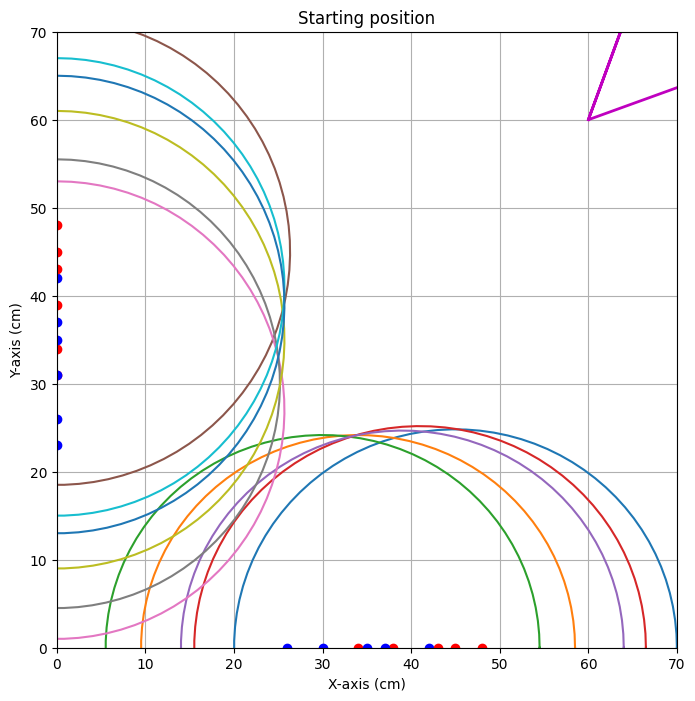


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.015


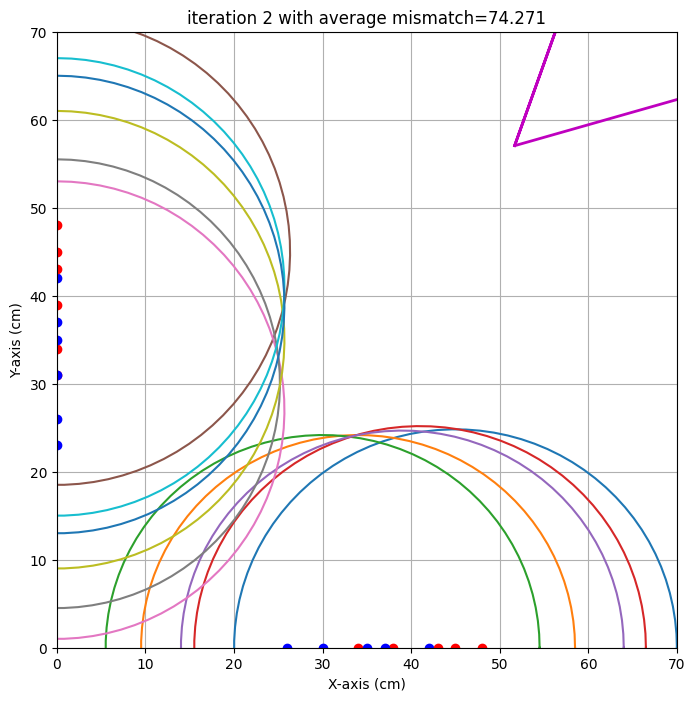

end iteration 2 with average mismatch=74.271


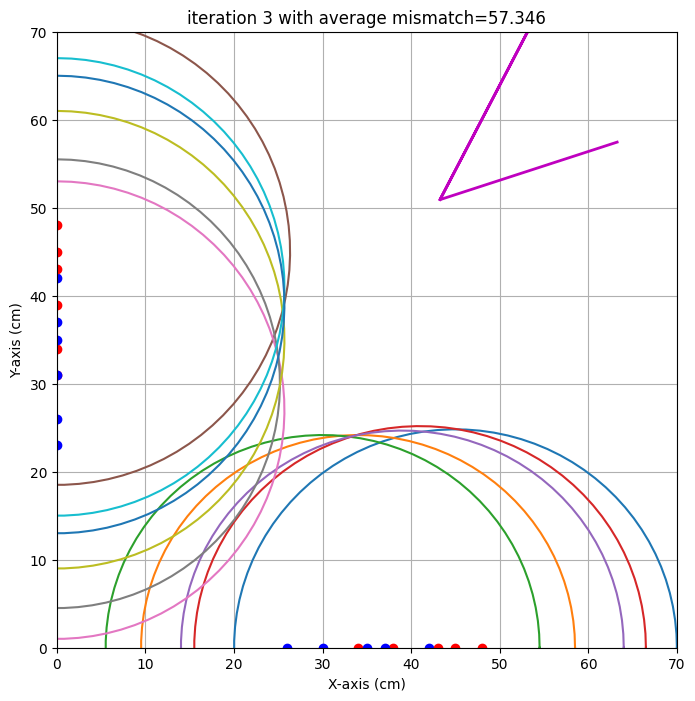

end iteration 3 with average mismatch=57.346


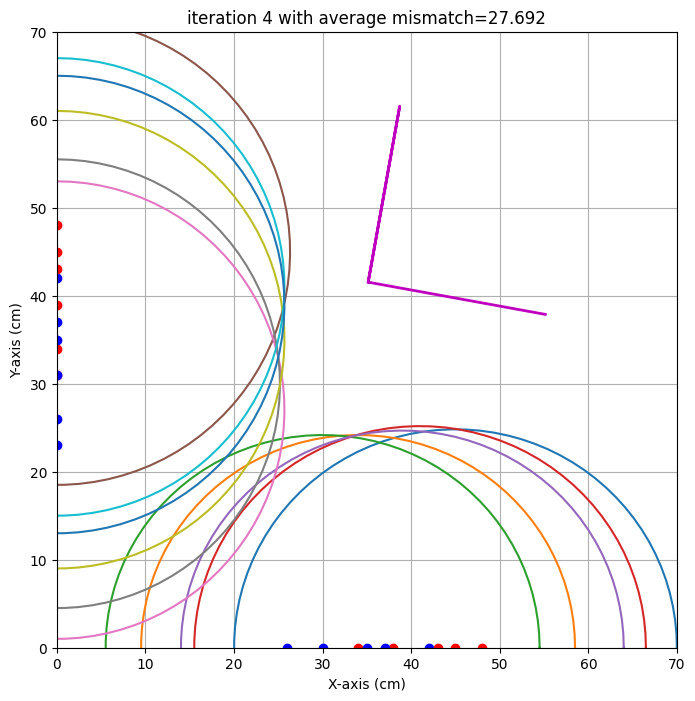

end iteration 4 with average mismatch=27.692


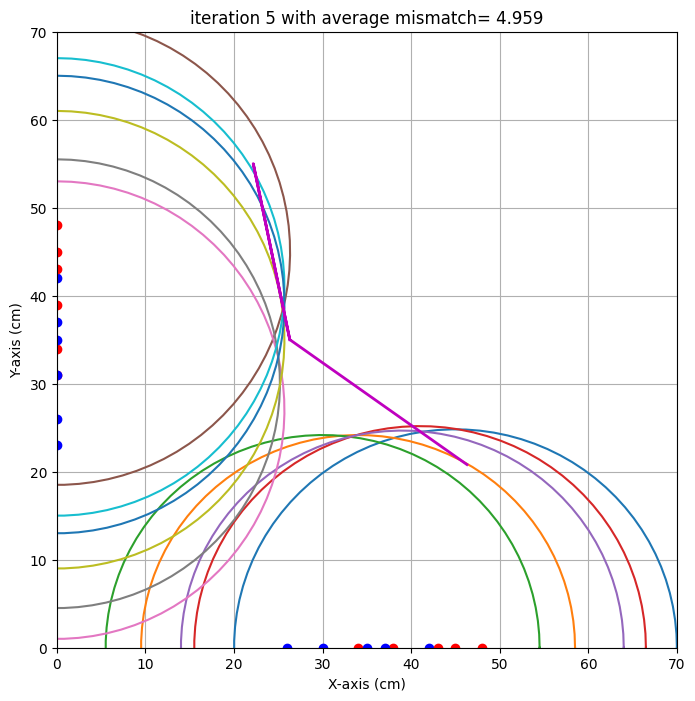

end iteration 5 with average mismatch= 4.959


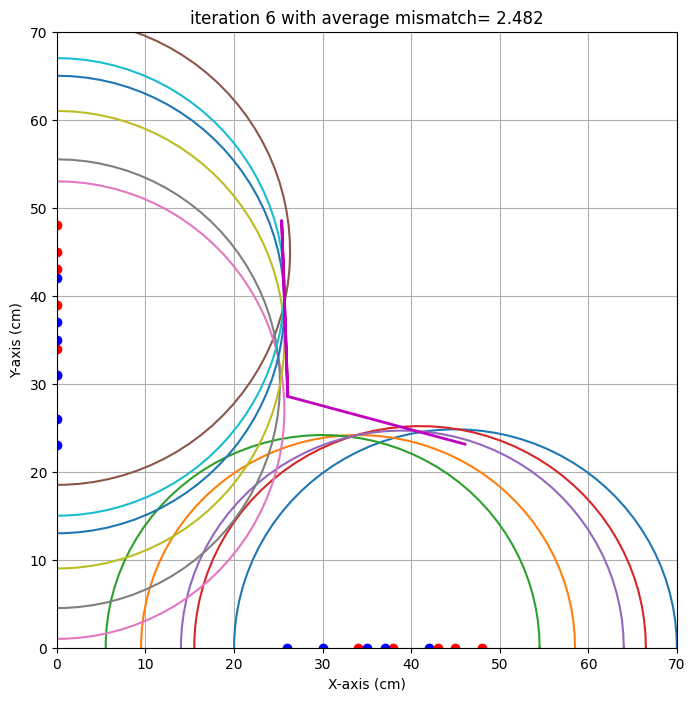

end iteration 6 with average mismatch= 2.482


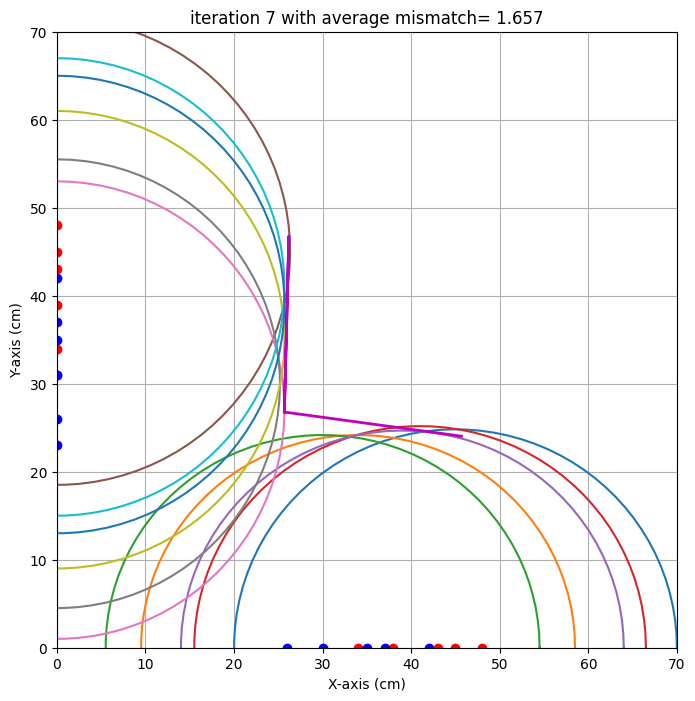

end iteration 7 with average mismatch= 1.657


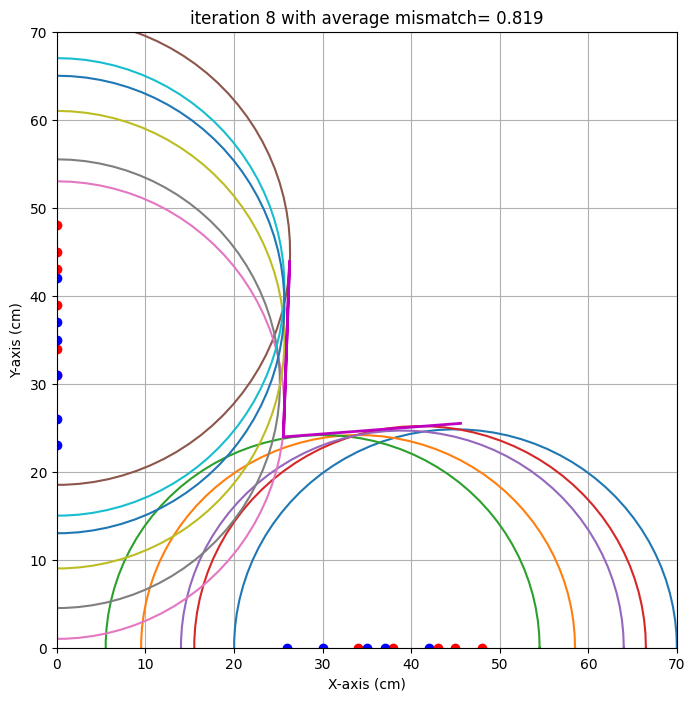

end iteration 8 with average mismatch= 0.819
end iteration 9 with average mismatch= 0.819
end iteration 10 with average mismatch= 0.819
end iteration 11 with average mismatch= 0.819
end iteration 12 with average mismatch= 0.818
end iteration 13 with average mismatch= 0.799
end iteration 14 with average mismatch= 0.788
end iteration 15 with average mismatch= 0.776
end iteration 16 with average mismatch= 0.751
end iteration 17 with average mismatch= 0.751
end iteration 18 with average mismatch= 0.751
end iteration 19 with average mismatch= 0.751
end iteration 20 with average mismatch= 0.751
end iteration 21 with average mismatch= 0.751
end iteration 22 with average mismatch= 0.751
end iteration 23 with average mismatch= 0.751
end iteration 24 with average mismatch= 0.751
end iteration 25 with average mismatch= 0.735
end iteration 26 with average mismatch= 0.683
end iteration 27 with average mismatch= 0.678
end iteration 28 with average mismatch= 0.674
end iteration 29 with average mismat

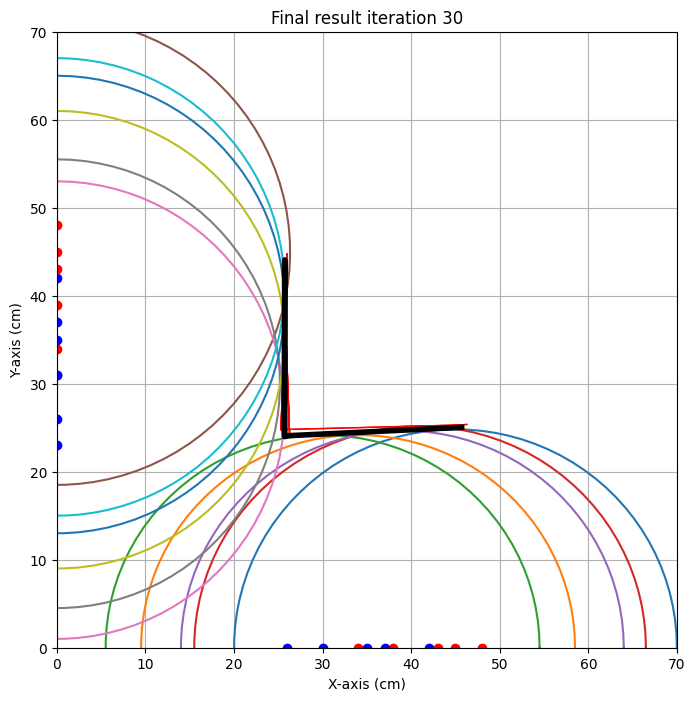

{'alpha': 2.7747279863872705, 'alpha_eps': 1.2856377410479916, 'beta': 0.07418702474619385, 'beta_eps': 2.1424925313141676, 'x0': 25.696392250308605, 'x0_eps': 0.5829069897785644, 'y0': 24.072978751032768, 'y0_eps': 0.7122751778397074}
test locatie 
x0 target is : 25.0. Gevonden waarde: 25.7 cm met een standaardafwijking van 0.6 cm 
y0 target is : 24.5. Gevonden waarde: 24.1 cm met een standaardafwijking van 0.7 cm 
alpha target is : 3.0. Gevonden waarde: 2.8 graden met een standaardafwijking van 1.3 graad 
beta target is : 5.0. Gevonden waarde: 0.1 graden met een standaardafwijking van 2.1 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:
#### een aanpassing aan het algoritme: de metingen worden sterker gespeid om een groter bereik te meten


# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  25,
                    'y0':  24.5,
                    'alpha' : 3 ,
                    'beta' : 5  
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [48,0,42,0,50],
    [34+4,0,34-4,0,49],
    [30+4,0,30-4,0,49],
    #[49+4,0,49-4,0,55],
    [41+4,0,41-4,0,51],
    #[51+4,0,51-4,0,143],
    [39+4,0,39-4,0,50],
    [0,48,0,42,53],
    [0,27+4,0,27-4,52],
    [0,30+4,0,30-4,51],
    [0,35+4,0,35-4,52],
    [0,41+4,0,41-4,52],
    #[0,47+4,0,47-4,112],
    [0,39+4,0,39-4,52],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](leerdoel_algoritme.jpg)

Figuur: ![Alt](20260318_141506.jpg)

Figuur: ![Alt](20260318_142418.jpg)